# Delayed latents across multiple groups (mDLAG) demo

In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import matplotlib.pyplot as plt
import numpy as np

from latents.observation_model.probabilistic import HyperPriorParams, ObsParamsARD
from latents.state_model.gaussian_process import (
    GPParams,
    construct_gp_covariance_matrix,
)
from latents.state_model.latents import StateParamsDelayed

from latents.plotting import hinton

from latents.mdlag.simulation import generate_latents, generate_observations

## Generate data from the mDLAG model

In [16]:
rng = np.random.default_rng(0)

In [26]:
# Dataset characteristics:
T = 25  # Number of samples per sequence
y_dims = np.array([10, 11, 12])
num_groups = len(y_dims)

x_dim = 7
binWidth = 20
snr = 10.0 * np.ones(len(y_dims))

# Define hyperpriors:
MAG = 100.0
sparsity_pattern = np.array(
    [
        [1, 1, 1, np.inf, 1, np.inf, np.inf],
        [1, 1, np.inf, 1, np.inf, 1, np.inf],
        [1, np.inf, 1, 1, np.inf, np.inf, 1],
    ]
)
hyper_priors_generate = HyperPriorParams(
    a_alpha=MAG * sparsity_pattern,
    b_alpha=MAG * np.ones_like(sparsity_pattern),
    a_phi=1.0,
    b_phi=1.0,
    d_beta=1.0,
)

# Define observation model parameters:
obs_params = ObsParamsARD.generate(y_dims, x_dim, hyper_priors_generate, snr, rng)

# Define GP parameters:
tau = np.array([30, 80, 50, 120, 100, 40, 70])  # GP timescales
eps = 1e-3 * np.ones(x_dim)  # GP noise variances
D = np.array(
    [[0, 0, 0, 0, 0, 0, 0], [15, -30, 0, 0, 0, 0, 0], [30, 0, -25, 40, 0, 0, 0]]
)
D = D / binWidth
gamma = (binWidth / tau) ** 2
"""
gamma_lim = (0.01,0.5)
eps_lim = (1e-4, 0.1)
delay_lim = (-5,5)
gp_params = GPParams.generate(x_dim, num_groups, delay_lim, eps_lim, gamma_lim, rng)
"""

gp_params = GPParams(gamma=gamma, eps=eps, D=D)

# Define state model parameters:
state_params_delayed = StateParamsDelayed(x_dim, num_groups, T)

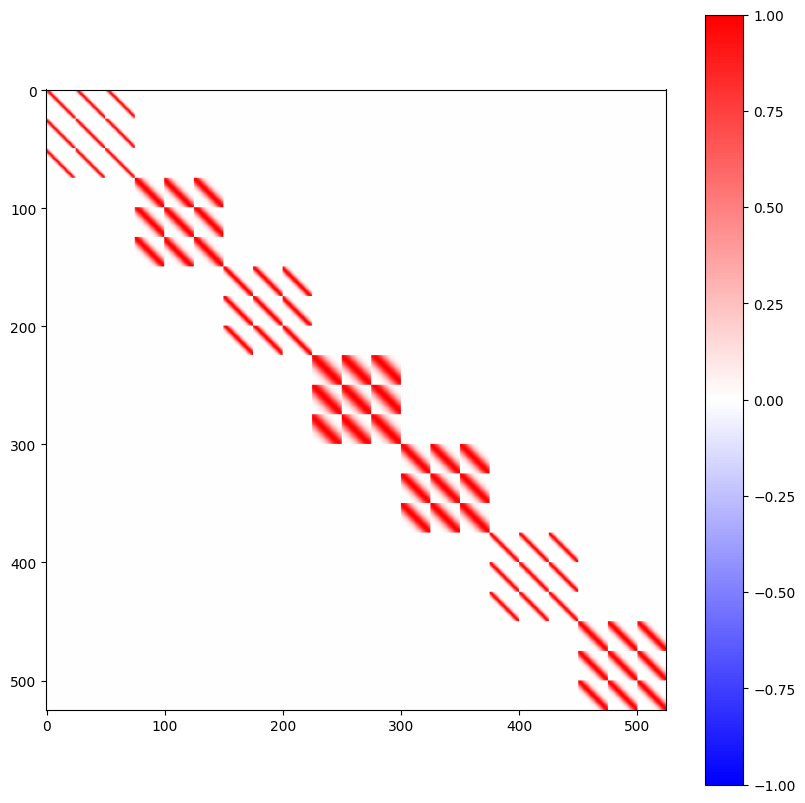

In [28]:
# To visualize the kernel matrix, we use order='C'.
# Otherwise, the matrix is returned in Fortran order.
K_big = construct_gp_covariance_matrix(
    gp_params=gp_params, T=T, return_tensor=False, order="C"
)

plt.figure(figsize=(10, 10))
plt.imshow(
    K_big,
    cmap="bwr",
    vmin=-np.abs(K_big).max(),
    vmax=np.abs(K_big).max(),
)
plt.colorbar()
plt.show()

# Generate data from the mDLAG model


In [43]:
N = 100
X = generate_latents(gp_params, T=T, N=100, rng=rng)
print(X.shape)
Y = generate_observations(X, obs_params, rng)
print(Y.data.shape)

(7, 3, 25, 100)
(33, 25, 100)


# Plot the latents:

<function matplotlib.pyplot.show(close=None, block=None)>

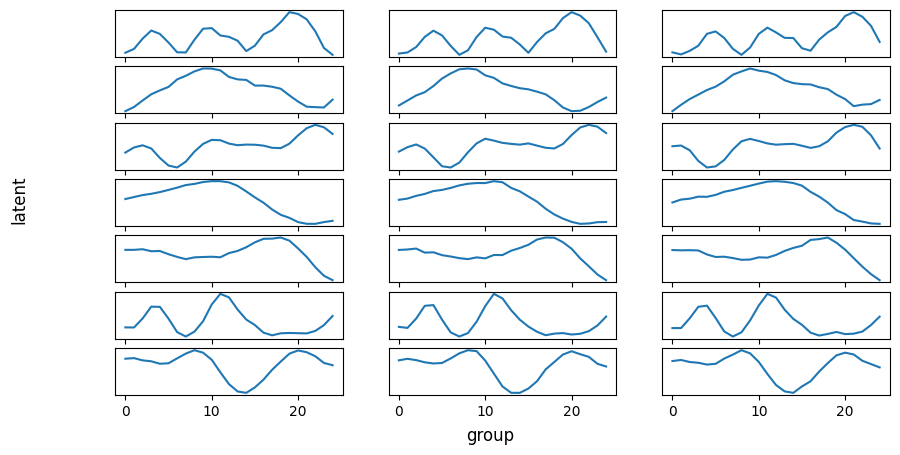

In [45]:
n = 0  # trial index we want to visualize
fig, ax = plt.subplots(x_dim, num_groups, figsize=(10, 5))

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        ax[i, j].plot(X[i, j, :, n])

plt.setp(ax, yticks=[])
fig.supxlabel("group")
fig.supylabel("latent")

plt.show

## Fit a mDLAG model to data

### Optional: Save the model to a file

### Optional: Load an existing model from a file

### Check fitting results

### Visualize recovery of select parameters

#### Loading matrices

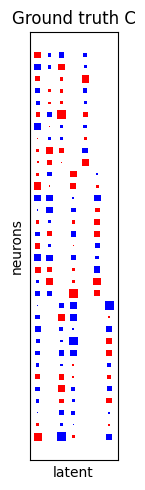

In [29]:
# Ground truth
plt.figure(figsize=(3, 5))
plt.subplot(1, 1, 1)
plt.title("Ground truth C")
hinton(obs_params.C.mean)
plt.xlabel("latent")
plt.ylabel("neurons")
plt.tight_layout()
plt.show()

#### ARD parameters

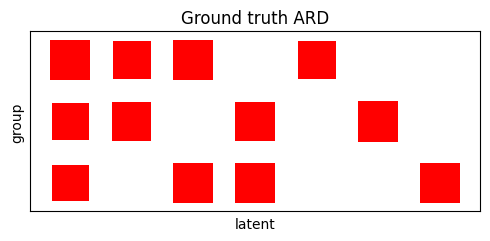

In [30]:
# Ground truth
# Compute the relative shared variance explained by each latent in each group
alpha_inv = 1 / obs_params.alpha.mean
alpha_inv_rel = alpha_inv / np.sum(alpha_inv, axis=1, keepdims=True)
plt.figure(figsize=(5, 3))
plt.subplot(1, 1, 1)
plt.title("Ground truth ARD")
hinton(alpha_inv_rel)
plt.xlabel("latent")
plt.ylabel("group")
plt.tight_layout()
plt.show()

In [46]:
# Create boolean mask for all latents (all True)
sig_dims = np.ones((num_groups, x_dim), dtype=bool)
# Convert GP parameters to time units
D = gp_params.D * binWidth  # Convert delays to milliseconds
tau = binWidth / np.sqrt(gp_params.gamma)  # Convert timescales to milliseconds
max_tau = np.max(tau)

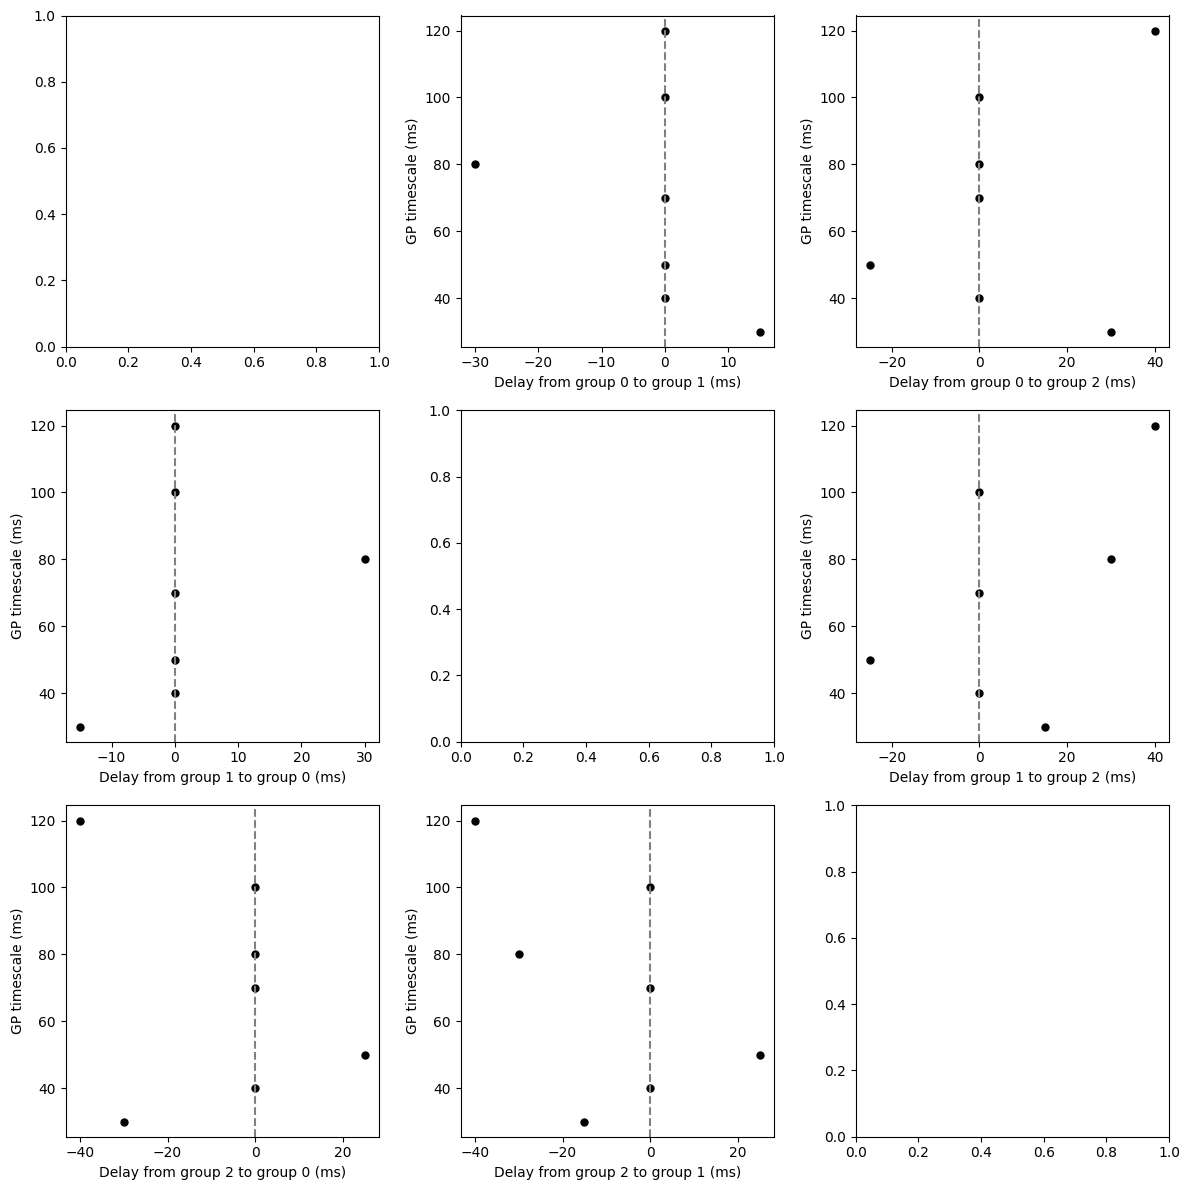

In [47]:
# 2. Plot shared latents (latents that appear in multiple groups)
fig, axes = plt.subplots(
    num_groups, num_groups, figsize=(4 * num_groups, 4 * num_groups)
)

for i in range(num_groups):
    for j in range(num_groups):
        if i != j:  # Only plot relationships between different groups
            # Calculate time delays between groups
            delays = D[j, :] - D[i, :]

            # Plot on the appropriate subplot
            ax = axes[i, j]
            ax.scatter(delays, tau, color="black", s=25)
            ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.5)

            # Labels and limits
            ax.set_xlabel(f"Delay from group {i} to group {j} (ms)")
            ax.set_ylabel("GP timescale (ms)")

plt.tight_layout()
plt.show()

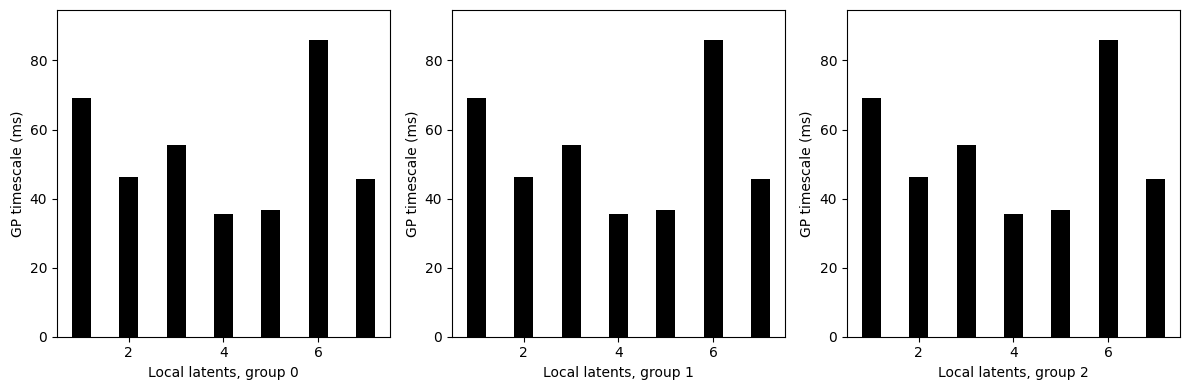

In [15]:
# 3. Plot local latents (latents unique to each group)
fig, axes = plt.subplots(1, num_groups, figsize=(4 * num_groups, 4))
if num_groups == 1:
    axes = [axes]

for group_idx in range(num_groups):
    ax = axes[group_idx]
    # Plot timescales as bar plot
    ax.bar(range(1, x_dim + 1), tau, width=0.4, color="black")

    # Labels and limits
    ax.set_ylabel("GP timescale (ms)")
    ax.set_xlabel(f"Local latents, group {group_idx}")
    ax.set_ylim([0, 1.1 * max_tau])

plt.tight_layout()
plt.show()

### Inferring latents and model parameters

Parameters can be easily inferred outside of the fitting procedure, as needed.

## Explore the model fit with various descriptive statistics

### Performance metrics: Evidence lower bound and leave-group-out prediction

### Estimated signal-to-noise ratios

### Determine and then visualize the dimensionalities of all types

### Perform a pairwise analysis of interactions between groups